# Récupérer des données historiques avec Interactive Brokers

Ce notebook montre comment utiliser l'API IBKR (via `ib_insync`) et IB GATEWAY pour :
1. **Daily** — Télécharger 10 ans d'OHLCV en une seule requête (ETFs multi-classes)
2. **Intraday** — Chunker des requêtes pour contourner les limites API (H1, H4, etc.)

### Prérequis

- Avoir un compte IBKR (même Paper Trading)
- IB Gateway ouvert et connecté au compte IBKR  
  https://www.interactivebrokers.com/en/trading/ibgateway-latest.php?p=stable

# Imports et configuration

In [1]:
from ib_insync import *
import nest_asyncio
nest_asyncio.apply()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from bokeh.plotting import figure, show
from bokeh.io import output_notebook, curdoc
from bokeh.models import Legend, HoverTool
from bokeh.palettes import Category10_6

from datetime import datetime, timedelta
import glob
import time
import os

plt.style.use('dark_background')

In [2]:
# Configuration initiale
nest_asyncio.apply()
DATA_DIR = './data'
os.makedirs(DATA_DIR, exist_ok=True)

In [3]:
SECTOR_ETFS = {
    # ── Bonds (1) ──
    'TLT':  {'asset_class': 'Bond',      'name': 'US Treasury 20Y+'},
    # ── Equities (3) ──
    'SPY':  {'asset_class': 'Equity',    'name': 'S&P 500'},
    'FEZ':  {'asset_class': 'Equity',    'name': 'Euro Stoxx 50'},
    'EEM':  {'asset_class': 'Equity',    'name': 'Emerging Markets'},
    # ── Commodities (2) ──
    'GLD':  {'asset_class': 'Commodity', 'name': 'Gold (Physical)'},
    'DBC':  {'asset_class': 'Commodity', 'name': 'Commodities Basket'},
}

In [4]:
# Creation connecteur
ib = IB()

# Connexion en mode lecture seule
ib.connect('127.0.0.1', 4002, clientId=1, readonly=True)

print(f"Début du téléchargement pour {len(SECTOR_ETFS)} secteurs...\n")

for ticker, info in SECTOR_ETFS.items():
    # 1. Création et qualification du contrat
    contract = Stock(ticker, 'SMART', 'USD')
    ib.qualifyContracts(contract)
    
    # 2. Requête One-Shot (10 ans)
    # Pour du '1 day', IB accepte plusieurs années sans broncher :) 
    bars = ib.reqHistoricalData(
        contract,
        endDateTime='', 
        durationStr='10 Y', 
        barSizeSetting='1 day', 
        whatToShow='TRADES',  # prix d'exécution réels (alternatives : MIDPOINT, BID, ASK, BID_ASK)
        useRTH=True  # Regular Trading Hours only (exclut pre/post-market)
    )
    
    if bars:
        df = util.df(bars)
        df['ticker'] = ticker
        df['asset_class'] = info['asset_class']
        
        file_path = os.path.join(DATA_DIR, f"{ticker}.csv")
        df.to_csv(file_path, index=False)
        print(f"✓ {ticker} ({info['name']}) : {len(df)} jours — {df['date'].iloc[0]} → {df['date'].iloc[-1]}")
    else:
        print(f"✗ Erreur pour {ticker}")

print("\nTerminé ! Tes fichiers sont dans :", DATA_DIR)

Début du téléchargement pour 6 secteurs...

✓ TLT (US Treasury 20Y+) : 2512 jours — 2016-03-07 → 2026-03-03
✓ SPY (S&P 500) : 2512 jours — 2016-03-07 → 2026-03-03
✓ FEZ (Euro Stoxx 50) : 2512 jours — 2016-03-07 → 2026-03-03
✓ EEM (Emerging Markets) : 2512 jours — 2016-03-07 → 2026-03-03
✓ GLD (Gold (Physical)) : 2512 jours — 2016-03-07 → 2026-03-03
✓ DBC (Commodities Basket) : 2512 jours — 2016-03-07 → 2026-03-03

Terminé ! Tes fichiers sont dans : ./data


---
### Affichage

In [5]:
# Charger tous les CSV et concaténer
csv_files = glob.glob(os.path.join(DATA_DIR, '*.csv'))
frames = []
for f in csv_files:
    tmp = pd.read_csv(f, parse_dates=['date'])
    frames.append(tmp)

all_data = pd.concat(frames, ignore_index=True)

# Mapper asset_class depuis SECTOR_ETFS
all_data['asset_class'] = all_data['ticker'].map(lambda t: SECTOR_ETFS[t]['asset_class'])
all_data['name']        = all_data['ticker'].map(lambda t: SECTOR_ETFS[t]['name'])

# Pivot : colonnes = tickers, index = date, valeurs = close
close_df = all_data.pivot(index='date', columns='ticker', values='close').sort_index()

# MultiIndex (date, ticker) pour affichage complet
mi_df = all_data.set_index(['date', 'ticker']).sort_index()

In [6]:
mi_df.tail()

open    high     low   close      volume  average  \
date       ticker                                                        
2026-03-03 EEM      57.97   58.91   56.74   58.42  85992756.0   57.775   
           FEZ      63.48   64.62   62.93   64.35   5438048.0   63.935   
           GLD     472.79  473.20  458.93  468.14  15761068.0  467.248   
           SPY     675.05  682.61  669.66  680.33  81440966.0  676.491   
           TLT      88.98   89.67   88.93   89.43  43321924.0   89.342   

                   barCount asset_class              name  
date       ticker                                          
2026-03-03 EEM       181515      Equity  Emerging Markets  
           FEZ        21012      Equity     Euro Stoxx 50  
           GLD       138681   Commodity   Gold (Physical)  
           SPY       818342      Equity           S&P 500  
           TLT        78357        Bond  US Treasury 20Y+

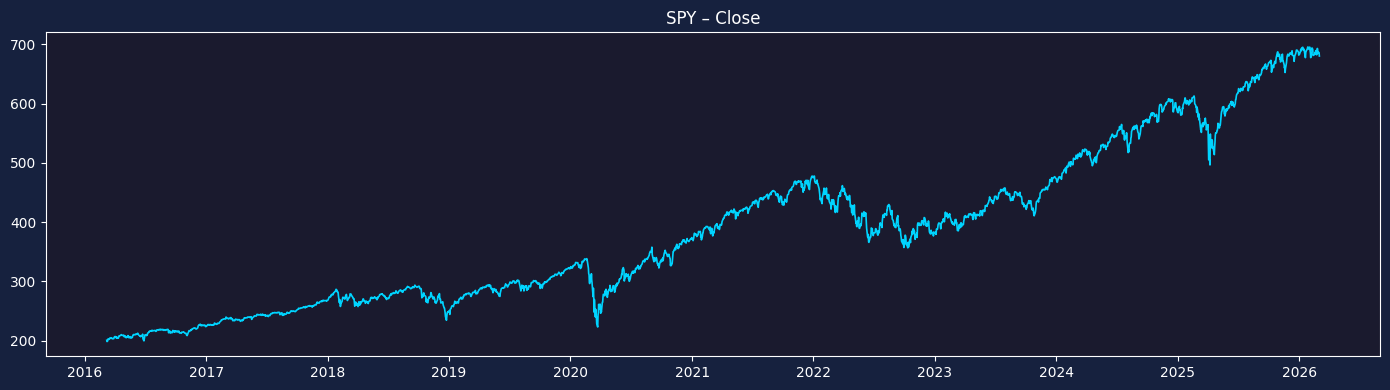

In [7]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(close_df.index, close_df['SPY'], color='#00d4ff', linewidth=1.2)
ax.set_title('SPY – Close')
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#16213e')
plt.tight_layout()
plt.show()

# Visualisation Bokeh (Dark Theme)

In [8]:
output_notebook()
curdoc().theme = 'night_sky'

# Aligner sur la première date commune à tous les ETFs (drop NaN)
close_aligned = close_df.dropna()

# Base 100 linéaire, axe Y log (style Bloomberg)
norm_df = close_aligned / close_aligned.iloc[0] * 100

p = figure(
    title="ETFs – Performance normalisée (base 100, log scale)",
    x_axis_type='datetime',
    y_axis_type='log',
    width=950, height=500,
    background_fill_color="#1a1a2e",
    border_fill_color="#16213e",
)

colors = Category10_6
legend_items = []

for i, ticker in enumerate(norm_df.columns):
    r = p.line(
        norm_df.index, norm_df[ticker],
        line_width=2, color=colors[i], alpha=0.9,
    )
    legend_items.append((f"{ticker} – {SECTOR_ETFS[ticker]['name']}", [r]))

legend = Legend(items=legend_items, location="top_left", label_text_color="white",
               click_policy="hide")
p.add_layout(legend, 'right')

p.add_tools(HoverTool(
    tooltips=[("Date", "$x{%F}"), ("Value", "$y{0.0f}")],
    formatters={"$x": "datetime"}, mode="vline"
))

p.title.text_color = "white"
p.xaxis.axis_label_text_color = "white"
p.yaxis.axis_label = "Performance (base 100)"
p.yaxis.axis_label_text_color = "white"
p.xaxis.major_label_text_color = "white"
p.yaxis.major_label_text_color = "white"
p.legend.background_fill_alpha = 0.3

show(p)

Loading BokehJS ...

# Matrice de corrélation

In [9]:
# Corrélation sur les rendements journaliers
returns = close_df.dropna().pct_change().dropna()

# Regrouper par asset class
order = ['TLT', 'SPY', 'FEZ', 'EEM', 'GLD', 'DBC']
corr = returns[order].corr()
tickers = list(corr.columns)

# Groupes pour les encadrés
groups = {
    'Bond':      {'tickers': ['TLT'],            'color': '#4fc3f7'},
    'Equity':    {'tickers': ['SPY', 'FEZ', 'EEM'], 'color': '#ff8a65'},
    'Commodity': {'tickers': ['GLD', 'DBC'],      'color': '#aed581'},
}

# Colorscale dark
dark_colorscale = [
    [0.0,  "#1e3a5f"],
    [0.25, "#2a4a6b"],
    [0.5,  "#2d2d3d"],
    [0.75, "#6b2a2a"],
    [1.0,  "#8b1a1a"],
]

fig = go.Figure(data=go.Heatmap(
    z=corr.values[::-1],
    x=tickers,
    y=tickers[::-1],
    zmin=-1, zmax=1,
    colorscale=dark_colorscale,
    text=np.round(corr.values[::-1], 2),
    texttemplate="%{text:.2f}",
    textfont=dict(size=13, color="white"),
    colorbar=dict(tickfont=dict(color="white"), title=dict(text="Corr", font=dict(color="white"))),
))

# Encadrer chaque groupe sur la diagonale
n = len(tickers)
for gname, ginfo in groups.items():
    idx_start = tickers.index(ginfo['tickers'][0])
    idx_end   = tickers.index(ginfo['tickers'][-1])

    x0 = idx_start - 0.5
    x1 = idx_end + 0.5
    y0 = (n - 1 - idx_end) - 0.5
    y1 = (n - 1 - idx_start) + 0.5

    fig.add_shape(type="rect", x0=x0, x1=x1, y0=y0, y1=y1,
                  line=dict(color=ginfo['color'], width=3),
                  xref="x", yref="y")

fig.update_layout(
    title=dict(text="Matrice de corrélation (rendements journaliers)", font=dict(color="white")),
    width=700, height=650,
    paper_bgcolor="#16213e",
    plot_bgcolor="#1a1a2e",
    xaxis=dict(tickfont=dict(color="white"), tickangle=45, side="bottom"),
    yaxis=dict(tickfont=dict(color="white")),
)
fig.show()

---

# Données Intraday (H1 / H4) — Chunking obligatoire

IBKR limite l'historique intraday :
| Bar Size | Max par requête | Stratégie pour 5-10 ans |
|----------|----------------|------------------------|
| 1 hour   | ~365 jours     | Chunker par blocs de 365 jours |
| 4 hours  | ~365 jours     | Chunker par blocs de 365 jours |
| 1 min    | ~30 jours      | Chunker par blocs de 30 jours |
| 1 sec    | ~1 jour        | Chunker par jour |

- Limitations API :  
  - https://ibkrcampus.com/campus/ibkr-api-page/twsapi-doc/#historical-data-limitations
  - https://ibkrcampus.com/campus/ibkr-api-page/twsapi-doc/#pacing-violations

In [10]:
# ── Exemple : SPY en H1 sur 5 ans (chunk par blocs de 365 jours) ──
# SMART = Smart Order Routing (IBKR choisit le meilleur exchange automatiquement)
contract = Stock('SPY', 'SMART', 'USD')
ib.qualifyContracts(contract)

# Paramètres
bar_size = '1 hour'          # ou '4 hours'
chunk_days = 365             # max ~365j par requête pour hourly
total_years = 5
end_dt = datetime.now()
start_dt = end_dt - timedelta(days=total_years * 365)

In [11]:
all_bars = []
current_end = end_dt
chunk_num = 0

while current_end > start_dt:
    chunk_num += 1
    end_str = current_end.strftime('%Y%m%d-%H:%M:%S')
    
    bars = ib.reqHistoricalData(
        contract,
        endDateTime=end_str,
        durationStr=f'{chunk_days} D',
        barSizeSetting=bar_size,
        whatToShow='TRADES',  # prix d'exécution réels (alternatives : MIDPOINT, BID, ASK, BID_ASK)
        useRTH=True  # Regular Trading Hours only (exclut pre/post-market)
    )
    
    if not bars:
        print(f"  Chunk {chunk_num} : aucune donnée, arrêt.")
        break
    
    all_bars = bars + all_bars  # prepend (ordre chronologique)
    print(f"  Chunk {chunk_num} OK — {len(bars)} barres — {bars[0].date} → {bars[-1].date}")
    
    # Reculer à la première barre reçue (strip tz pour rester naive comme start_dt)
    current_end = bars[0].date.replace(tzinfo=None)
    
    # Respect pacing IBKR (max 6 req / 2 sec)
    time.sleep(2)

  Chunk 1 OK — 2540 barres — 2024-09-17 09:30:00-04:00 → 2026-03-03 15:00:00-05:00
  Chunk 2 OK — 2546 barres — 2023-04-04 09:30:00-04:00 → 2024-09-16 15:00:00-04:00
  Chunk 3 OK — 2549 barres — 2021-10-20 09:30:00-04:00 → 2023-04-03 15:00:00-04:00
  Chunk 4 OK — 2549 barres — 2020-05-11 09:30:00-04:00 → 2021-10-19 15:00:00-04:00


In [12]:
# Assemblage final
df_intraday = util.df(all_bars)
df_intraday['date'] = pd.to_datetime(df_intraday['date'])
df_intraday = df_intraday.drop_duplicates(subset=['date']).sort_values('date').set_index('date')

print(f"\nSPY {bar_size} : {len(df_intraday)} barres du {df_intraday.index[0]} au {df_intraday.index[-1]}")

# Sauvegarde
INTRADAY_DIR = './data/sector_etfs_intraday'
os.makedirs(INTRADAY_DIR, exist_ok=True)
df_intraday.to_csv(os.path.join(INTRADAY_DIR, f"SPY_{bar_size.replace(' ', '')}.csv"))
print(f"Sauvegardé dans {INTRADAY_DIR}/SPY_{bar_size.replace(' ', '')}.csv")


SPY 1 hour : 10184 barres du 2020-05-11 09:30:00-04:00 au 2026-03-03 15:00:00-05:00
Sauvegardé dans ./data/sector_etfs_intraday/SPY_1hour.csv


In [13]:
df_intraday.head()

,open,high,low,close,volume,average,barCount
date,,,,,,,
2020-05-11 09:30:00-04:00,290.34,291.21,289.88,290.48,7138164.0,290.633,33389
2020-05-11 10:00:00-04:00,290.45,291.41,290.38,290.88,9271368.0,290.946,45100
2020-05-11 11:00:00-04:00,290.88,292.00,290.82,291.95,5939633.0,291.557,29319
2020-05-11 12:00:00-04:00,291.93,293.11,291.71,292.98,5909650.0,292.578,26914
2020-05-11 13:00:00-04:00,292.98,294.00,292.77,293.36,5688769.0,293.534,26001


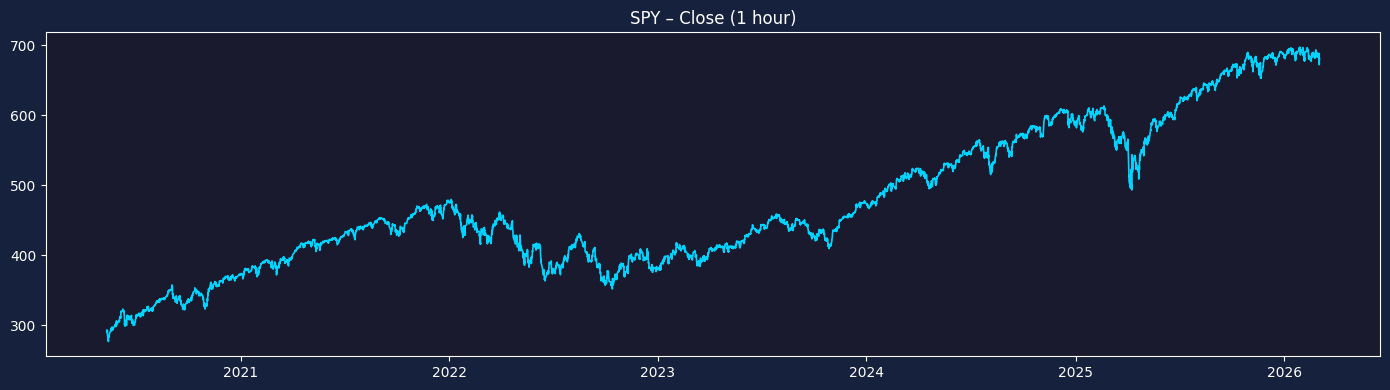

In [14]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_intraday.index, df_intraday['close'], color='#00d4ff', linewidth=1.2)
ax.set_title(f'SPY – Close ({bar_size})')
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#16213e')
plt.tight_layout()
plt.show()

In [15]:
# Deconnection Client
ib.disconnect()

---